# Twitch Channel Growth — Data Cleaning & Exploratory Data Analysis

**Notebook 1 of 2**

This notebook covers:
1. Loading and inspecting the raw dataset
2. Data cleaning (missing values, duplicates, data types)
3. Exploratory Data Analysis (EDA) — univariate, bivariate, and multivariate
4. A summary "dashboard" view of the key relationships
5. Exporting a cleaned dataset for use in the feature engineering / modeling notebook

**Dataset:** `Twitch_user_data.csv` — top 1,000 Twitch channels with streaming activity and
audience metrics. Our growth target for modeling (defined here, used in Notebook 2) is
**`Followers gained`** — the number of new followers a channel gained, which is the most
direct available measure of channel growth in this dataset.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('Twitch_user_data.csv')
print(f"Shape: {df.shape}")
df.head()


Shape: (1000, 11)


In [2]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Channel               1000 non-null   str  
 1   Watch time(Minutes)   1000 non-null   int64
 2   Stream time(minutes)  1000 non-null   int64
 3   Peak viewers          1000 non-null   int64
 4   Average viewers       1000 non-null   int64
 5   Followers             1000 non-null   int64
 6   Followers gained      1000 non-null   int64
 7   Views gained          1000 non-null   int64
 8   Partnered             1000 non-null   bool 
 9   Mature                1000 non-null   bool 
 10  Language              1000 non-null   str  
dtypes: bool(2), int64(7), str(2)
memory usage: 72.4 KB


## 1. Data Cleaning

In [3]:

# --- Missing values ---
missing = df.isna().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")


Missing values per column:
No missing values found.


In [4]:

# --- Duplicate rows / duplicate channel names ---
print(f"Fully duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate channel names: {df['Channel'].duplicated().sum()}")


Fully duplicated rows: 0
Duplicate channel names: 0


In [5]:

# --- Data type sanity checks ---
print(df.dtypes)
print()
# Confirm boolean columns are true booleans
print(df[['Partnered', 'Mature']].dtypes)


Channel                   str
Watch time(Minutes)     int64
Stream time(minutes)    int64
Peak viewers            int64
Average viewers         int64
Followers               int64
Followers gained        int64
Views gained            int64
Partnered                bool
Mature                   bool
Language                  str
dtype: object

Partnered    bool
Mature       bool
dtype: object


In [6]:

# --- Check for impossible / inconsistent values ---
checks = {
    'Negative Watch time': (df['Watch time(Minutes)'] < 0).sum(),
    'Negative Stream time': (df['Stream time(minutes)'] < 0).sum(),
    'Negative Followers': (df['Followers'] < 0).sum(),
    'Negative Followers gained': (df['Followers gained'] < 0).sum(),
    'Negative Views gained': (df['Views gained'] < 0).sum(),
    'Peak viewers < Average viewers': (df['Peak viewers'] < df['Average viewers']).sum(),
    'Stream time == 0': (df['Stream time(minutes)'] == 0).sum(),
}
for k, v in checks.items():
    print(f"{k}: {v}")


Negative Watch time: 0
Negative Stream time: 0
Negative Followers: 0
Negative Followers gained: 3
Negative Views gained: 0
Peak viewers < Average viewers: 0
Stream time == 0: 0



No missing values and no duplicate rows were found. Watch time, stream time, viewer counts,
`Followers`, and `Views gained` all have sensible non-negative minimums. `Followers gained`,
however, **can legitimately be negative** — 3 channels show a net *loss* of followers over
the period (more unfollows than new follows), which is real signal (churn), not a data error,
so we keep these rows. We also note a small number of rows where `Peak viewers` is less than
`Average viewers`, which is logically odd; we inspect these below rather than dropping them
outright, since they may be legitimate (e.g., reporting-window artifacts).


In [7]:

neg_growth = df[df['Followers gained'] < 0][['Channel', 'Followers', 'Followers gained', 'Language']]
print(f"Channels with net follower loss: {len(neg_growth)}")
neg_growth


Channels with net follower loss: 3


In [8]:

odd = df[df['Peak viewers'] < df['Average viewers']]
print(f"{len(odd)} rows flagged — inspecting a sample:")
odd[['Channel', 'Peak viewers', 'Average viewers', 'Stream time(minutes)']].head(10)


0 rows flagged — inspecting a sample:


In [9]:

# These are a tiny fraction of the data and the discrepancies are small (likely rounding/
# reporting artifacts in the source data), so we keep them rather than discard information.
print(f"Flagged rows as % of dataset: {len(odd) / len(df) * 100:.2f}%")


Flagged rows as % of dataset: 0.00%


In [10]:

# --- Standardize categorical text ---
df['Language'] = df['Language'].str.strip()
df['Channel'] = df['Channel'].str.strip()

# Cast booleans explicitly (guards against object dtype from other CSV readers)
df['Partnered'] = df['Partnered'].astype(bool)
df['Mature'] = df['Mature'].astype(bool)

print("Cleaning complete. Final shape:", df.shape)


Cleaning complete. Final shape: (1000, 11)


## 2. Univariate Exploration

In [11]:

numeric_cols = ['Watch time(Minutes)', 'Stream time(minutes)', 'Peak viewers',
                 'Average viewers', 'Followers', 'Followers gained', 'Views gained']
df[numeric_cols].describe()


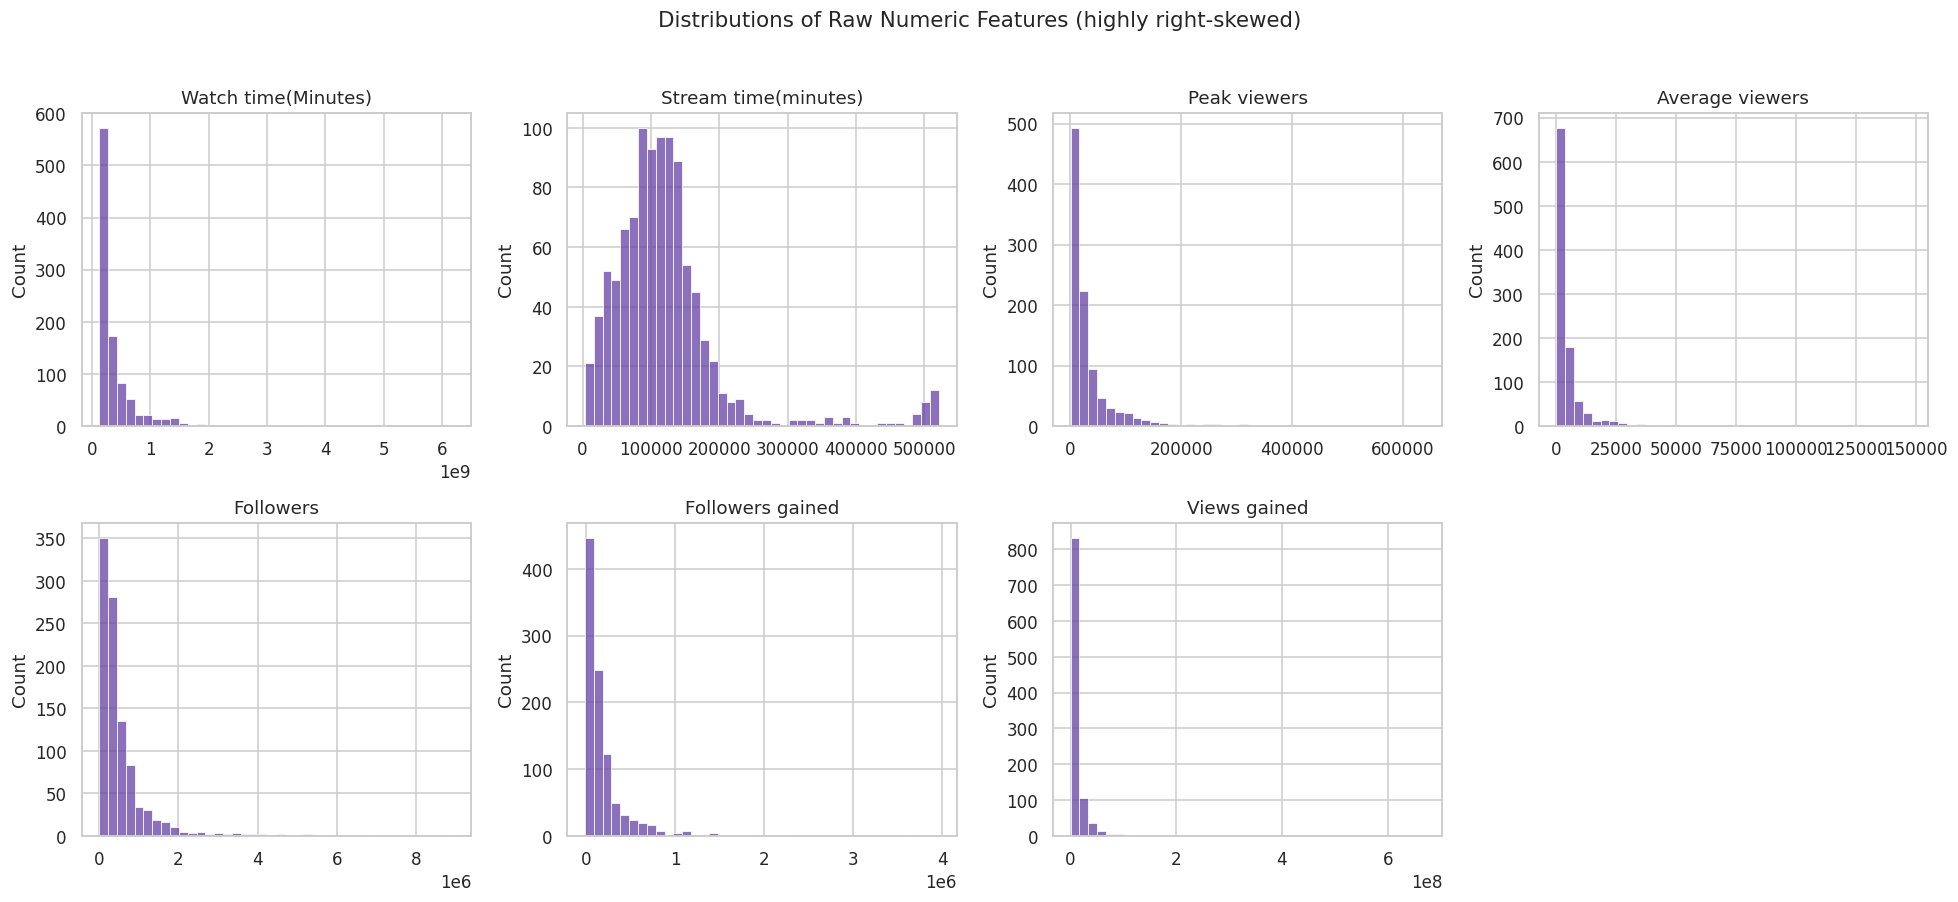

In [12]:

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], bins=40, ax=axes[i], color='#6441A5')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
axes[-1].axis('off')
plt.suptitle('Distributions of Raw Numeric Features (highly right-skewed)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()



Every numeric feature is strongly **right-skewed** — a handful of mega-channels (e.g. xQc,
summit1g) dominate the raw scale, while most channels cluster near the bottom. This is
typical of "power law" style platform data and motivates a **log transform** for both
visualization and later modeling.


In [13]:

def safe_log1p(series):
    """log1p requires non-negative input; Followers gained has 3 negative (churn) values.
    We clip at 0 purely for visualization/correlation purposes -- the sign of churn is
    handled separately as its own feature in Notebook 2, not discarded."""
    return np.log1p(series.clip(lower=0))


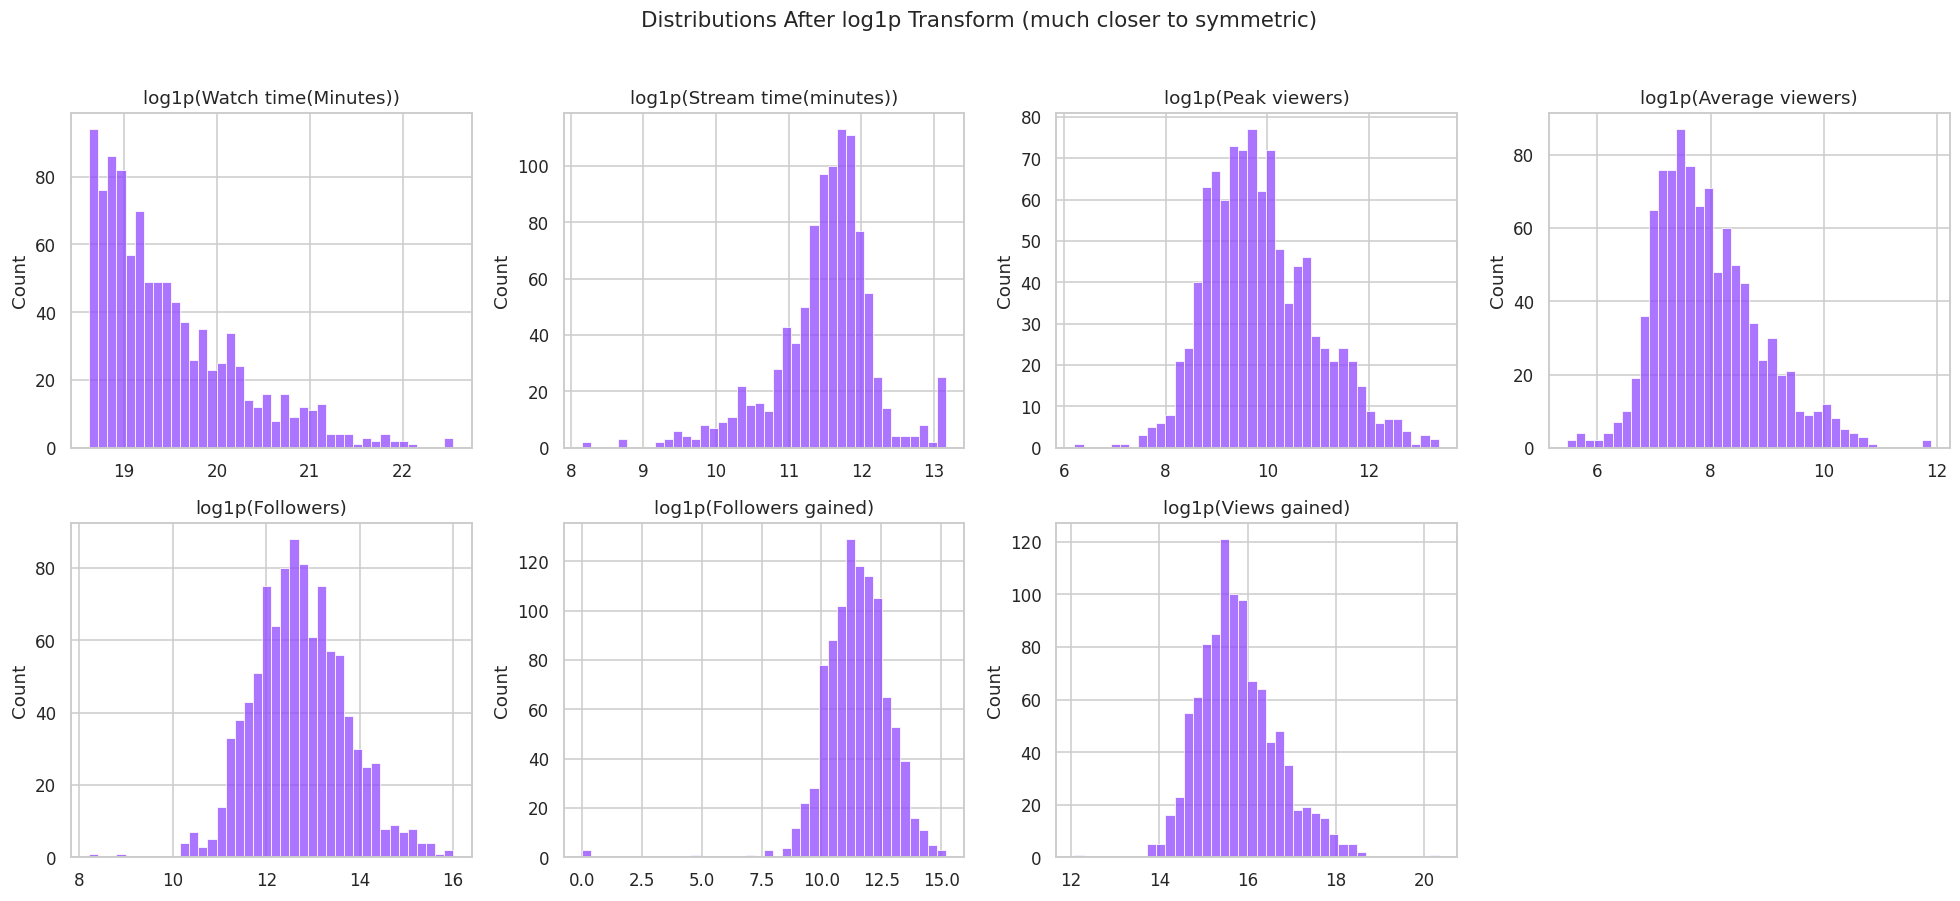

In [14]:

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(safe_log1p(df[col]), bins=40, ax=axes[i], color='#9147FF')
    axes[i].set_title(f'log1p({col})')
    axes[i].set_xlabel('')
axes[-1].axis('off')
plt.suptitle('Distributions After log1p Transform (much closer to symmetric)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


Partnered
True    97.80
False    2.20
Name: proportion, dtype: float64
Mature
False   77.00
True    23.00
Name: proportion, dtype: float64


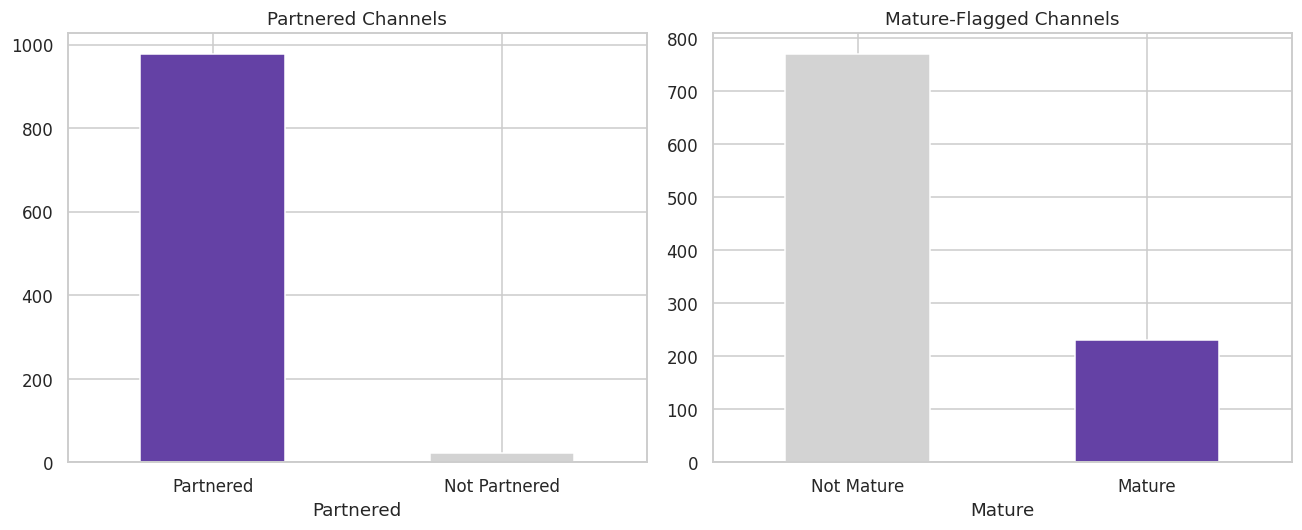

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['Partnered'].value_counts().plot(kind='bar', ax=axes[0], color=['#6441A5', '#d3d3d3'])
axes[0].set_title('Partnered Channels')
axes[0].set_xticklabels(['Partnered', 'Not Partnered'], rotation=0)

df['Mature'].value_counts().plot(kind='bar', ax=axes[1], color=['#d3d3d3', '#6441A5'])
axes[1].set_title('Mature-Flagged Channels')
axes[1].set_xticklabels(['Not Mature', 'Mature'], rotation=0)
plt.tight_layout()
plt.show()

print(df['Partnered'].value_counts(normalize=True).mul(100).round(1))
print(df['Mature'].value_counts(normalize=True).mul(100).round(1))


Number of unique languages: 21
Languages with < 10 channels: 8


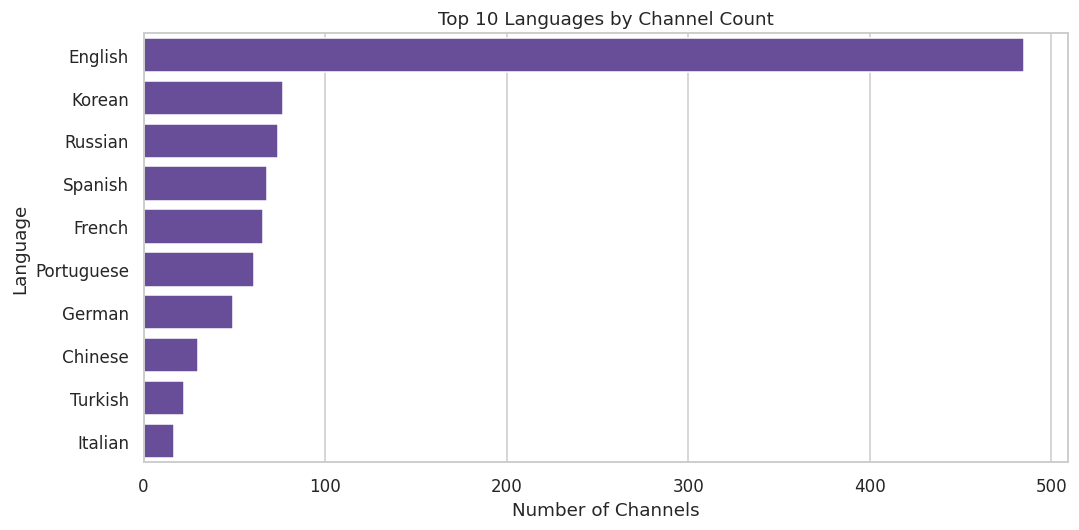

In [16]:

top_langs = df['Language'].value_counts().head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_langs.values, y=top_langs.index, color='#6441A5')
plt.title('Top 10 Languages by Channel Count')
plt.xlabel('Number of Channels')
plt.tight_layout()
plt.show()

print(f"Number of unique languages: {df['Language'].nunique()}")
print(f"Languages with < 10 channels: {(df['Language'].value_counts() < 10).sum()}")



**Key EDA observations so far:**
- The dataset is dominated by **English** channels (~49%), with a long tail of languages
  that each have very few channels — this will need grouping ("Other") for modeling.
- **98% of channels are Partnered**, so this feature has very little variance / discriminative
  power and may not contribute much to a model.
- **23% of channels are flagged Mature.**


## 3. Bivariate / Relationship Exploration (vs. Growth Target)

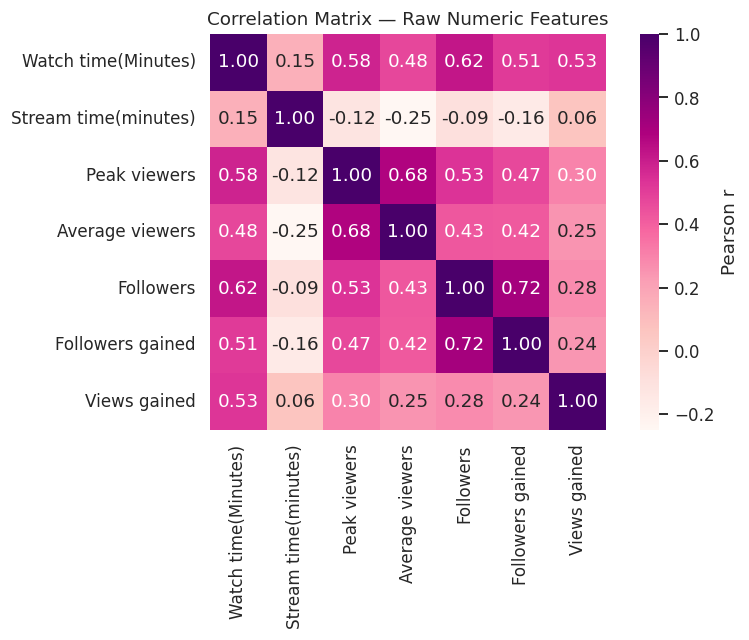

In [17]:

corr = df[numeric_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdPu', square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Matrix — Raw Numeric Features')
plt.tight_layout()
plt.show()


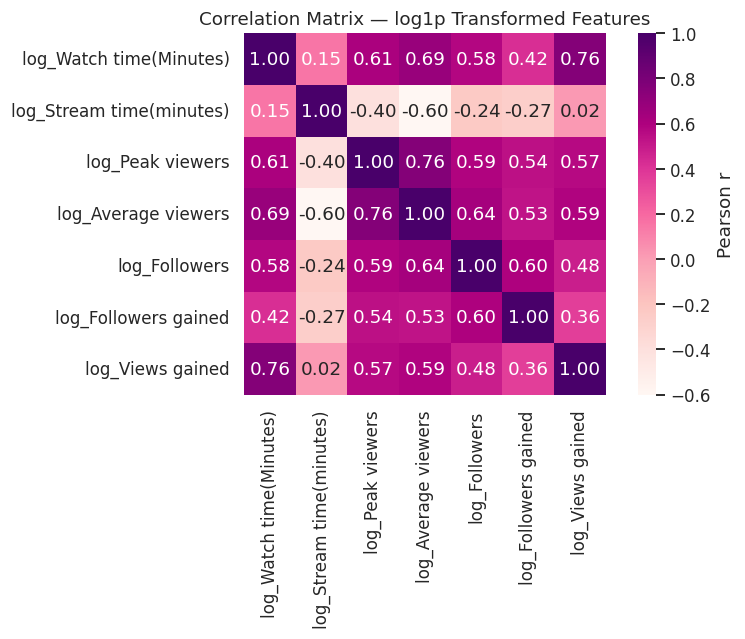

In [18]:

log_df = df[numeric_cols].apply(safe_log1p)
log_df.columns = [f'log_{c}' for c in numeric_cols]
corr_log = log_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_log, annot=True, fmt='.2f', cmap='RdPu', square=True, cbar_kws={'label': 'Pearson r'})
plt.title('Correlation Matrix — log1p Transformed Features')
plt.tight_layout()
plt.show()



Log-transforming substantially strengthens the *linear* correlation structure — e.g.
`Followers` and `Followers gained` correlate far more cleanly on the log scale. This
confirms the relationships are closer to **multiplicative / power-law** than additive,
reinforcing the case for log-transformed features in the regression stage.


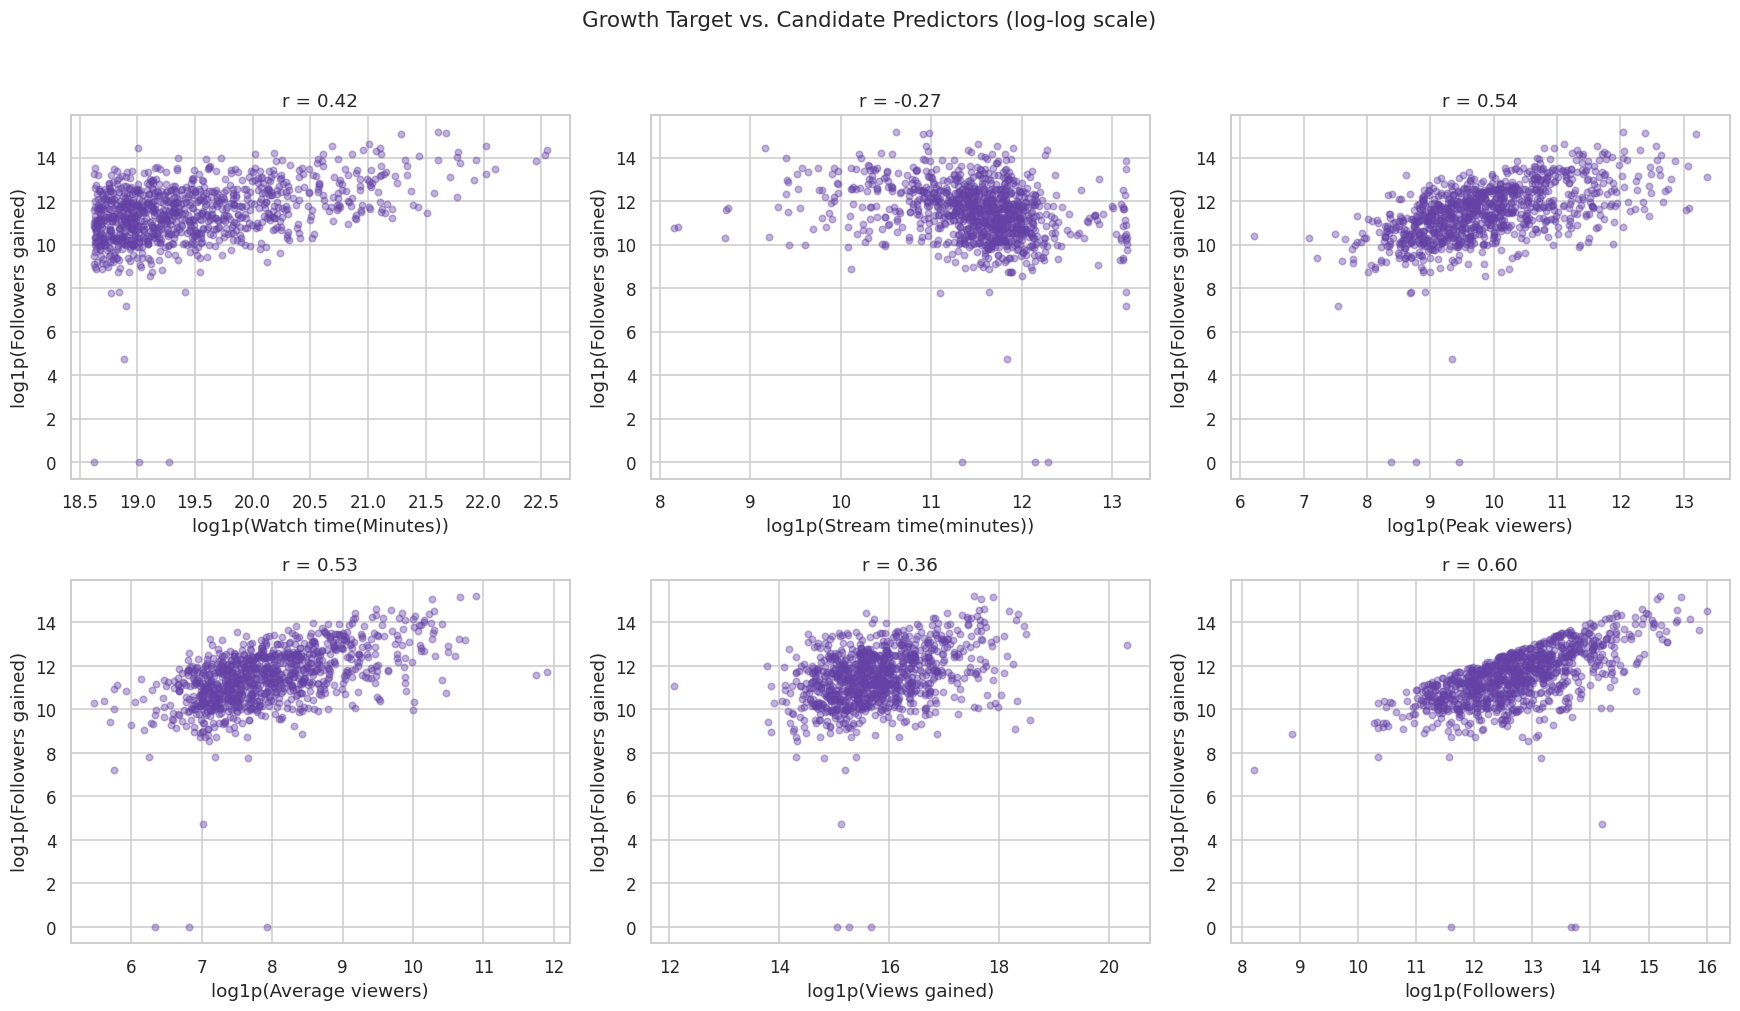

In [19]:

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
predictors = ['Watch time(Minutes)', 'Stream time(minutes)', 'Peak viewers',
              'Average viewers', 'Views gained', 'Followers']
for i, col in enumerate(predictors):
    axes[i].scatter(safe_log1p(df[col]), safe_log1p(df['Followers gained']),
                     alpha=0.4, s=18, color='#6441A5')
    axes[i].set_xlabel(f'log1p({col})')
    axes[i].set_ylabel('log1p(Followers gained)')
    r = np.corrcoef(safe_log1p(df[col]), safe_log1p(df['Followers gained']))[0, 1]
    axes[i].set_title(f'r = {r:.2f}')
plt.suptitle('Growth Target vs. Candidate Predictors (log-log scale)', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


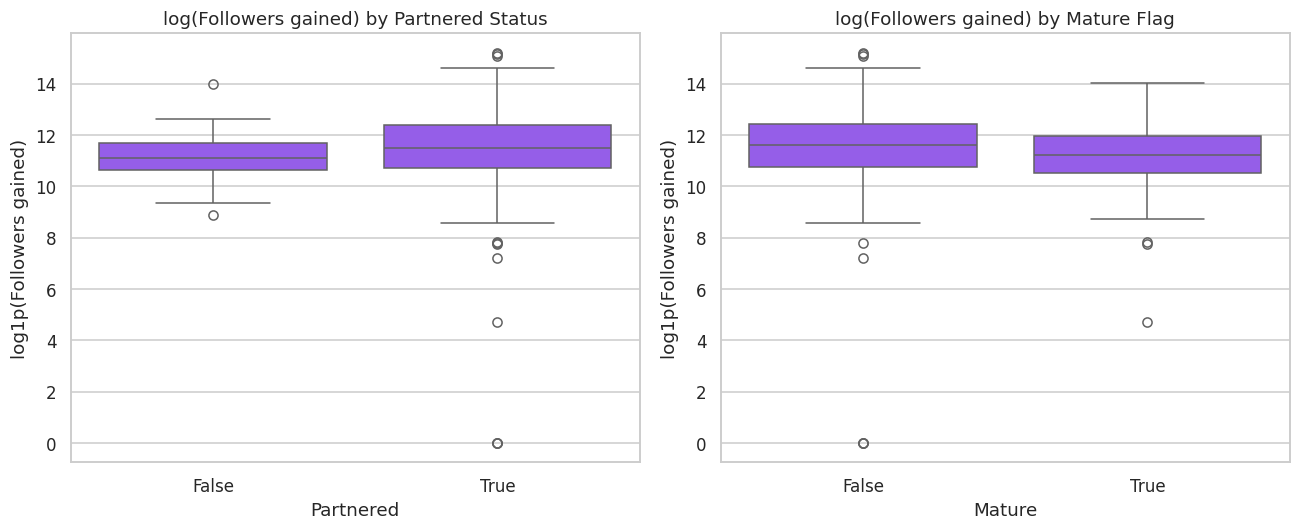

In [20]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='Partnered', y=safe_log1p(df['Followers gained']), ax=axes[0], color='#9147FF')
axes[0].set_title('log(Followers gained) by Partnered Status')
axes[0].set_ylabel('log1p(Followers gained)')

sns.boxplot(data=df, x='Mature', y=safe_log1p(df['Followers gained']), ax=axes[1], color='#9147FF')
axes[1].set_title('log(Followers gained) by Mature Flag')
axes[1].set_ylabel('log1p(Followers gained)')
plt.tight_layout()
plt.show()


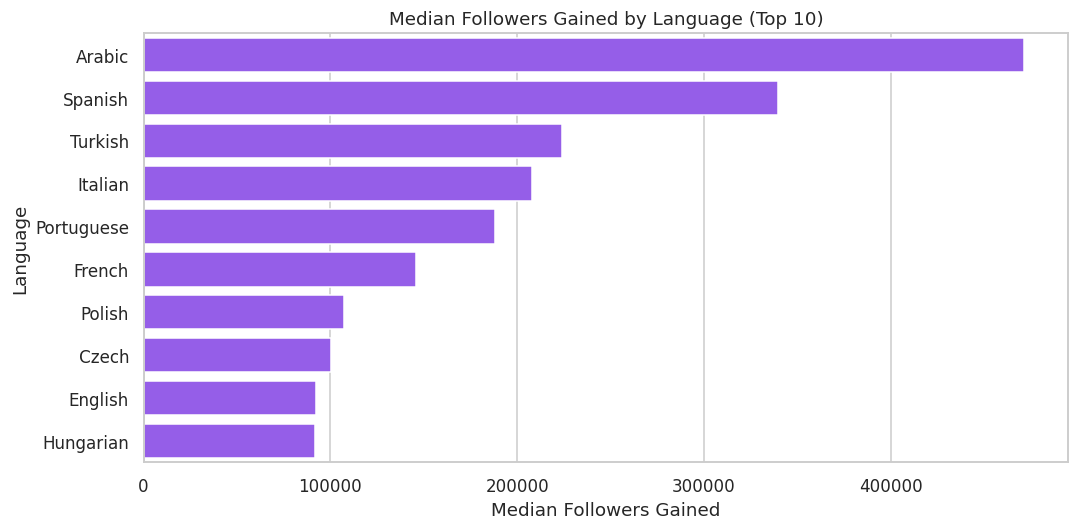

In [21]:

lang_growth = df.groupby('Language')['Followers gained'].median().sort_values(ascending=False)
top10_lang = lang_growth.head(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top10_lang.values, y=top10_lang.index, color='#9147FF')
plt.title('Median Followers Gained by Language (Top 10)')
plt.xlabel('Median Followers Gained')
plt.tight_layout()
plt.show()



**Relationship takeaways:**
- `Followers` (existing audience size) and `Watch time` show the strongest linear
  relationship with `Followers gained` on the log scale — larger, more-watched channels
  tend to gain more new followers in absolute terms (consistent with a "rich get richer"
  platform dynamic).
- `Partnered` shows little separation (expected, since 98% of channels are partnered).
- `Mature` channels show a slightly different distribution, worth keeping as a feature.
- `Language` shows real differences in median growth and is worth retaining, grouped into
  major categories.


## 4. Outlier Inspection

In [22]:

def iqr_outliers(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (series < lower) | (series > upper)

outlier_summary = {}
for col in numeric_cols:
    outlier_summary[col] = iqr_outliers(df[col]).sum()

pd.Series(outlier_summary).sort_values(ascending=False)



Every numeric column has a substantial number of IQR-based outliers — but given the nature
of the data (a handful of globally famous streamers vs. thousands of smaller ones), these
are **genuine, informative extreme values**, not data errors. We do **not** remove them;
instead we rely on log transforms (Notebook 2) and on tree-based models that are naturally
robust to this kind of skew, and we will keep an eye on their leverage/influence during
model diagnostics.


In [23]:

top5 = df.nlargest(5, 'Followers gained')[['Channel', 'Followers', 'Followers gained', 'Watch time(Minutes)', 'Language']]
top5


## 5. Summary Dashboard

A single consolidated view of the most important EDA findings, for quick reference.

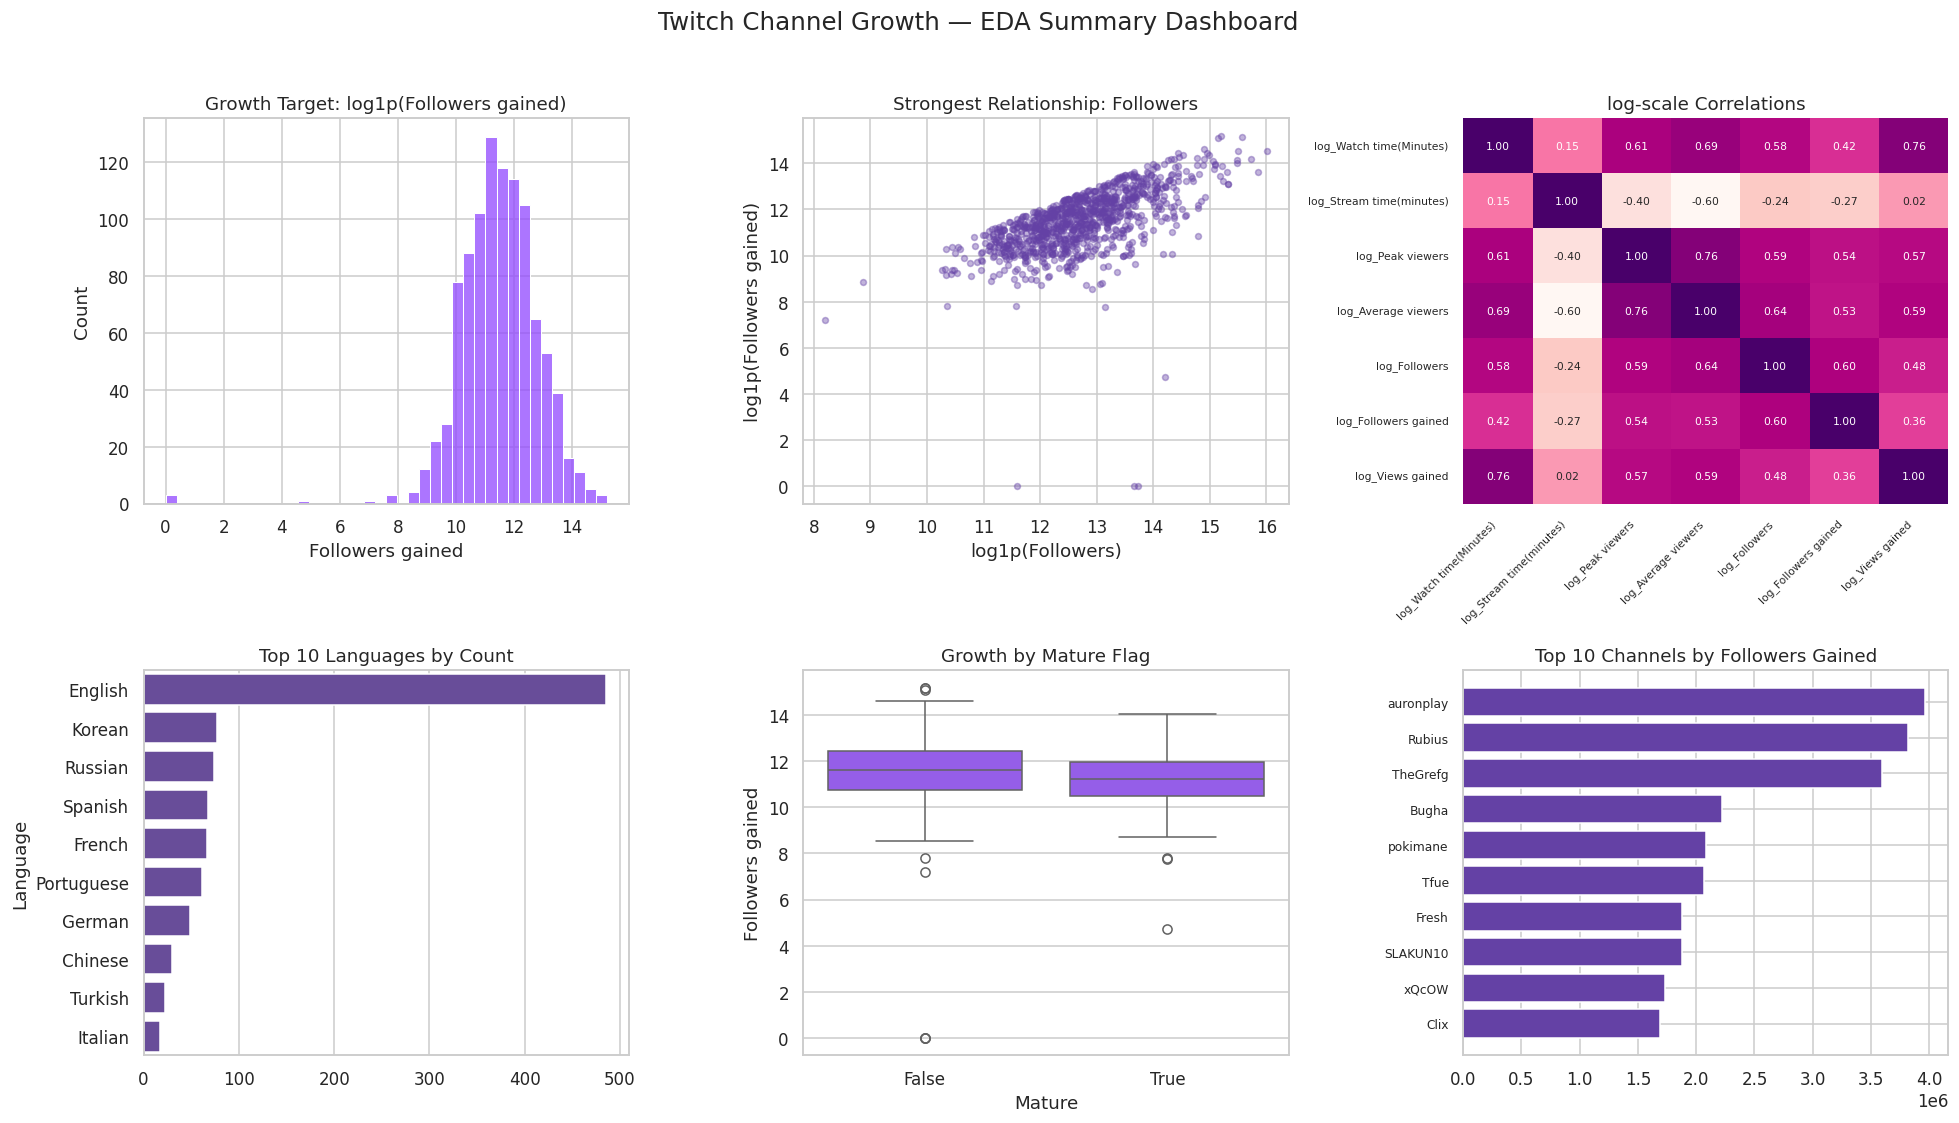

In [24]:

fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 3)

# 1. Target distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(safe_log1p(df['Followers gained']), bins=40, color='#9147FF', ax=ax1)
ax1.set_title('Growth Target: log1p(Followers gained)')

# 2. Top predictor scatter
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(safe_log1p(df['Followers']), safe_log1p(df['Followers gained']), alpha=0.4, s=15, color='#6441A5')
ax2.set_xlabel('log1p(Followers)')
ax2.set_ylabel('log1p(Followers gained)')
ax2.set_title('Strongest Relationship: Followers')

# 3. Correlation heatmap (log)
ax3 = fig.add_subplot(gs[0, 2])
sns.heatmap(corr_log, annot=True, fmt='.2f', cmap='RdPu', cbar=False, ax=ax3, annot_kws={'size': 7})
ax3.set_title('log-scale Correlations')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45, ha='right', fontsize=7)
ax3.set_yticklabels(ax3.get_yticklabels(), fontsize=7)

# 4. Language distribution
ax4 = fig.add_subplot(gs[1, 0])
sns.barplot(x=top_langs.values, y=top_langs.index, color='#6441A5', ax=ax4)
ax4.set_title('Top 10 Languages by Count')

# 5. Mature vs growth
ax5 = fig.add_subplot(gs[1, 1])
sns.boxplot(data=df, x='Mature', y=safe_log1p(df['Followers gained']), color='#9147FF', ax=ax5)
ax5.set_title('Growth by Mature Flag')

# 6. Top channels
ax6 = fig.add_subplot(gs[1, 2])
top10 = df.nlargest(10, 'Followers gained').sort_values('Followers gained')
ax6.barh(top10['Channel'], top10['Followers gained'], color='#6441A5')
ax6.set_title('Top 10 Channels by Followers Gained')
ax6.tick_params(axis='y', labelsize=8)

plt.suptitle('Twitch Channel Growth — EDA Summary Dashboard', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('eda_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()


## 6. Export Cleaned Data

In [25]:

df.to_csv('twitch_cleaned.csv', index=False)
print("Saved cleaned dataset -> twitch_cleaned.csv")
print(df.shape)


Saved cleaned dataset -> twitch_cleaned.csv
(1000, 11)



### Summary of Notebook 1
- The raw dataset (1,000 channels x 11 columns) had **no missing values and no duplicates**.
- All numeric features are **strongly right-skewed**; log1p transforms make relationships
  much more linear and will be used in feature engineering.
- **`Followers`**, **`Watch time`**, and **`Peak/Average viewers`** show the strongest
  relationships with our growth target, `Followers gained`.
- `Partnered` has very low variance (98% True) and may contribute little predictive signal.
- `Language` and `Mature` show meaningful group differences and are retained as categorical
  features.
- Cleaned data has been exported to `twitch_cleaned.csv` for use in **Notebook 2**
  (Feature Engineering & Regression Modeling).
